In [91]:
# %%capture
!pip install gensim
!pip install pyvi

In [92]:
import nltk
import re
nltk.download('stopwords')
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

from gensim.corpora.dictionary import Dictionary
from gensim import corpora
from gensim.models import LsiModel, TfidfModel
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import Nmf
from gensim.models import LdaModel

from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from pyvi import ViTokenizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [93]:
stopwords_link = 'https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/refs/heads/master/vietnamese-stopwords.txt'
response = requests.get(stopwords_link)
stopwords = set(response.text.splitlines())

In [94]:
data = [
    "Trời đang mưa rất to, tôi định đi bộ đến trường. Nhưng do mưa ngập nên tôi đã học online tại nhà.",
    "Mình vừa hoàn thành bài tập môn Phân tích khai phá dữ liệu. Những thuật toán này rất ảo ma và làm đau đầu.",
    "Cuối tuần này, gia đình tôi sẽ tổ chức một bữa tiệc nhỏ. Chúng tôi sẽ cùng nhau nấu ăn và chia sẻ những kỷ niệm đẹp.",
    "Tôi rất thích nghe nhạc vào buổi tối. Âm nhạc giúp tôi thư giãn và tạo cảm hứng cho những ý tưởng mới.",
    "Học tiếng anh là một quá trình gian nan và lâu dài. Tôi thường lên các trang luyện nghe và đọc Ielts để nâng cao mức điểm của mình.",
    "Mỗi sáng, tôi thường  thể dục để giữ sức khỏe. Việc này không chỉ giúp tôi khỏe mạnh mà còn tạo năng lượng cho cả ngày.",
    "Tôi thích khám phá những món ăn mới. Mỗi lần thử một món ăn mới, tôi lại cảm thấy như đang trải nghiệm một cuộc phiêu lưu.",
    "Việc đọc sách giúp tôi mở mang kiến thức và cải thiện khả năng tư duy. Tôi thường dành thời gian mỗi ngày để đọc ít nhất một chương sách.",
    "Tôi rất yêu thiên nhiên và thường đi leo núi vào cuối tuần. Cảm giác chinh phục đỉnh núi mang lại cho tôi niềm vui và sự tự hào.",
    "Công nghệ trí tuệ nhân tạo ngày càng phát triển, ảnh hưởng đến mọi lĩnh vực trong cuộc sống. Tôi bắt đầu lo lắng vì tăng xác suất thất nghiệp."
]

In [95]:
def preprocess_data(doc_set):
    texts = []
    characters = [ ".", ",", "!", "?", ":", ";", "'", '"',"-","_","(", ")","[", "]", "{", "}", "<", ">", "/", "\\",
                  "|", "~", "`", "!", "@", "#", "$", "%", "^", "&", "*", "(", ")", "_", "+", "=" ]
    for i in doc_set:
        raw = i.lower()
        text = re.sub(r'[^a-zàáạảãăắằặẳẵâấầậẩẫèéẹẻẽêếềệểễìíịỉĩòóọỏõôốồộổỗơớờợởỡùúụủũưứừựửữýỳỵỷỹđ\s]', '', raw)
        tokens = ViTokenizer.tokenize(raw).split()
        tokens = [x.replace('_', ' ') for x in tokens]
        # Use the custom stopwords set loaded from the URL
        stopped_tokens = [x for x in tokens if x not in stopwords]
        stopped_tokens = [x for x in stopped_tokens if x not in characters]
        texts.append(stopped_tokens)
    return texts

Số văn bản: 10
Số topics: 3

 BƯỚC 1: TIỀN XỬ LÝ VĂN BẢN 

Đã tiền xử lý 10 văn bản

 BƯỚC 2: TẠO TỪ ĐIỂN VÀ CORPUS 

Số từ trong từ điển ban đầu: 77
Số từ sau khi lọc: 77
Số văn bản trong corpus: 10

Ví dụ corpus văn bản đầu tiên (5 từ đầu):
  học: 1 lần
  mưa: 2 lần
  ngập: 1 lần
  online: 1 lần
  to: 1 lần

 BƯỚC 3: TÍNH TF-IDF 

Đã tạo mô hình TF-IDF
Số văn bản: 10

 Bước 4: Phân tích SVD 

Kích thước ma trận TF-IDF: (10, 77)

Kết quả SVD:
- Ma trận U (document-topic): (10, 3)
- Singular values (Σ): [1.0637147 1.0326748 1.021671 ]
- Ma trận V^T (topic-term): (3, 77)

Phương sai được giải thích:
  Topic 0: 6.58%
  Topic 1: 11.23%
  Topic 2: 9.93%
Tổng: 27.73%


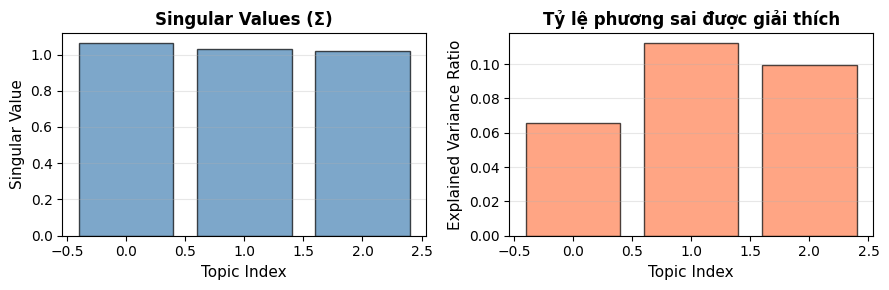

BƯỚC 5: Xây dựng Mô hình LSI
Đã tạo mô hình LSI với 3 topics

Các chủ đề (Topics):
------------------------------------------------------------

Topic 0:
  đọc                  : -0.3859
  sách                 : -0.3528
  giúp                 : -0.2176
  gian nan             : -0.1994
  trang                : -0.1994
  lâu dài              : -0.1994
  luyện                : -0.1994
  ielts                : -0.1994
  nâng                 : -0.1994
  tiếng                : -0.1994

Topic 1:
  núi                  : -0.2960
  mưa                  : -0.2717
  tuần                 : -0.2051
  đi                   : -0.1984
  giúp                 : +0.1768
  năng lượng           : +0.1659
  sức khỏe             : +0.1659
  thể dục              : +0.1659
  khỏe mạnh            : +0.1659
  vui                  : -0.1480

Topic 2:
  khỏe mạnh            : -0.2245
  thể dục              : -0.2245
  sức khỏe             : -0.2245
  năng lượng           : -0.2245
  núi                  : -0.2161
 

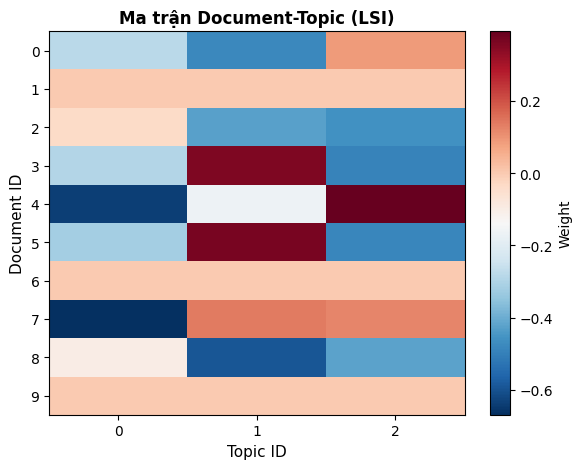


 BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH (3 LOẠI COHERENCE) 

Coherence c_v   : 0.2924
Coherence c_uci : -14.1198
Coherence c_npmi: -0.2301
(Giá trị càng cao càng tốt, thường trong khoảng 0–1)


 Tìm số Topic tối ưu 

Đang thử với số topics từ 2 đến 7...
  2 topics: 0.3093
  3 topics: 0.3321
  4 topics: 0.2805
  5 topics: 0.2999
  6 topics: 0.3083
  7 topics: 0.2793

 Số topics tối ưu: 3 (Coherence: 0.3321)


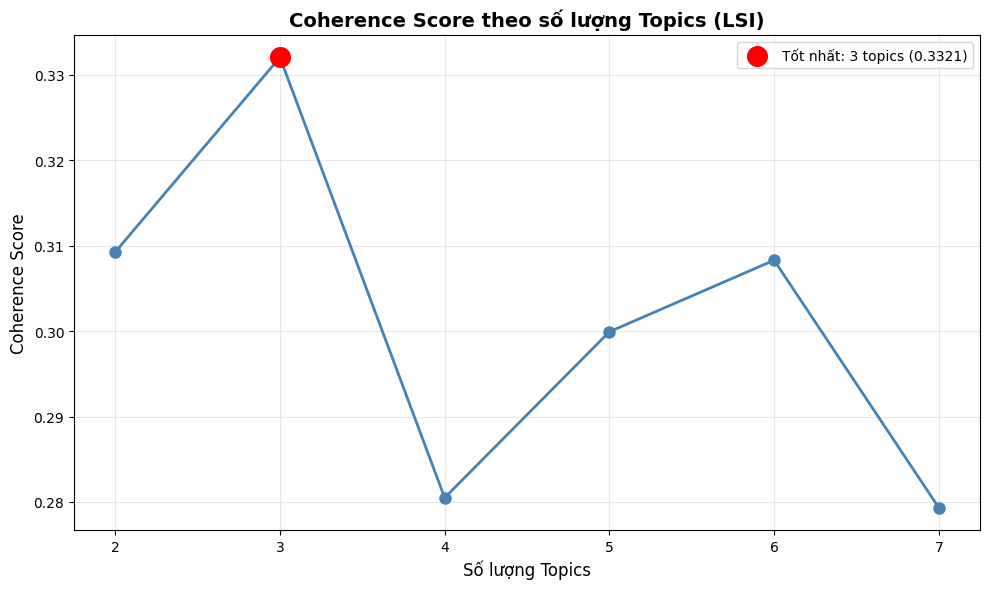


 BƯỚC 8: DỰ ĐOÁN TOPIC CHO VĂN BẢN MỚI 

Văn bản: Tôi không thường xuyên đọc sách về lịch sử và văn hóa Việt Nam.
Sau tiền xử lý: thường xuyên đọc sách lịch sử văn hóa việt nam

Phân bố topics:
  Topic 0: -0.5103
  Topic 1: +0.0715
  Topic 2: +0.1384

Topic chủ đạo: Topic 0 (weight: -0.5103)

Các từ quan trọng trong topic 0:
  đọc                  : -0.3859
  sách                 : -0.3528
  giúp                 : -0.2176
  gian nan             : -0.1994
  trang                : -0.1994
  lâu dài              : -0.1994
  luyện                : -0.1994
  ielts                : -0.1994
  nâng                 : -0.1994
  tiếng                : -0.1994
BƯỚC 9: LƯU MÔ HÌNH
Đã lưu các file:
  ✓ lsi_model.model
  ✓ dictionary.dict
  ✓ tfidf_model.model

 Đã hoàn thành quy trình Thuật toán LSI 



In [96]:
# ===========================
# THUẬT TOÁN LSI - TỪNG BƯỚC LÀ MỘT HÀM
# ===========================

def create_dictionary_and_corpus(processed_docs, no_below=1, no_above=0.8):
    """
    BƯỚC 2: Tạo từ điển và Corpus (Bag-of-Words)
    Input: Danh sách văn bản đã tiền xử lý
    Output: Dictionary và Corpus
    """
    print("\n BƯỚC 2: TẠO TỪ ĐIỂN VÀ CORPUS \n")

    # Tạo từ điển
    dictionary = corpora.Dictionary(processed_docs)
    print(f"Số từ trong từ điển ban đầu: {len(dictionary)}")

    # Lọc từ xuất hiện quá ít hoặc quá nhiều
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    print(f"Số từ sau khi lọc: {len(dictionary)}")

    # Tạo corpus (Bag-of-Words)
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
    print(f"Số văn bản trong corpus: {len(corpus)}")

    # Hiển thị ví dụ
    if corpus:
        print(f"\nVí dụ corpus văn bản đầu tiên (5 từ đầu):")
        for word_id, freq in corpus[0][:5]:
            print(f"  {dictionary[word_id]}: {freq} lần")

    return dictionary, corpus


def compute_tfidf(corpus):
    """
    BƯỚC 3: Tính TF-IDF (Term Frequency-Inverse Document Frequency)
    Input: Corpus BOW
    Output: TF-IDF model và corpus TF-IDF
    """
    print("\n BƯỚC 3: TÍNH TF-IDF \n")

    # Tạo mô hình TF-IDF
    tfidf_model = TfidfModel(corpus)
    corpus_tfidf = tfidf_model[corpus]

    print(f"Đã tạo mô hình TF-IDF")
    print(f"Số văn bản: {len(corpus)}")

    return tfidf_model, corpus_tfidf


def perform_svd(corpus_tfidf, dictionary, num_topics=3):
    """
    BƯỚC 4: Thực hiện SVD (Singular Value Decomposition)
    Input: Corpus TF-IDF, Dictionary, số topics
    Output: Ma trận U, Sigma, Vt và mô hình SVD
    """
    print("\n Bước 4: Phân tích SVD \n")

    # Chuyển corpus sang ma trận dense
    tfidf_matrix = corpus2dense(corpus_tfidf, len(dictionary)).T
    print(f"Kích thước ma trận TF-IDF: {tfidf_matrix.shape}")

    # Thực hiện SVD
    svd_model = TruncatedSVD(n_components=num_topics, random_state=42)
    U = svd_model.fit_transform(tfidf_matrix)
    Vt = svd_model.components_
    Sigma = svd_model.singular_values_

    print(f"\nKết quả SVD:")
    print(f"- Ma trận U (document-topic): {U.shape}")
    print(f"- Singular values (Σ): {Sigma}")
    print(f"- Ma trận V^T (topic-term): {Vt.shape}")

    # Phương sai được giải thích
    explained_var = svd_model.explained_variance_ratio_
    print(f"\nPhương sai được giải thích:")
    for i, var in enumerate(explained_var):
        print(f"  Topic {i}: {var:.2%}")
    print(f"Tổng: {sum(explained_var):.2%}")

    return U, Sigma, Vt, svd_model


def visualize_svd(Sigma, explained_var):
    """
    Visualize kết quả SVD
    """
    plt.figure(figsize=(9, 3))

    # Singular values
    plt.subplot(1, 2, 1)
    plt.bar(range(len(Sigma)), Sigma, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Topic Index', fontsize=11)
    plt.ylabel('Singular Value', fontsize=11)
    plt.title('Singular Values (Σ)', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    # Explained variance
    plt.subplot(1, 2, 2)
    plt.bar(range(len(explained_var)), explained_var, color='coral', alpha=0.7, edgecolor='black')
    plt.xlabel('Topic Index', fontsize=11)
    plt.ylabel('Explained Variance Ratio', fontsize=11)
    plt.title('Tỷ lệ phương sai được giải thích', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


def build_lsi_model(corpus_tfidf, dictionary, num_topics=3):
    """
    BƯỚC 5: Xây dựng mô hình LSI
    Input: Corpus TF-IDF, Dictionary, số topics
    Output: Mô hình LSI
    """
    print("BƯỚC 5: Xây dựng Mô hình LSI")

    # Tạo mô hình LSI
    lsi_model = LsiModel(corpus=corpus_tfidf,
                         id2word=dictionary,
                         num_topics=num_topics)

    print(f"Đã tạo mô hình LSI với {num_topics} topics")

    # Hiển thị các topics
    print(f"\nCác chủ đề (Topics):")
    print("-" * 60)
    for topic_id in range(num_topics):
        print(f"\nTopic {topic_id}:")
        topic_terms = lsi_model.show_topic(topic_id, topn=10)
        for term, weight in topic_terms:
            print(f"  {term:20s} : {weight:+.4f}")

    return lsi_model


def transform_documents(lsi_model, corpus_tfidf, data):
    """
    BƯỚC 6: Biểu diễn văn bản trong không gian Topics
    Input: Mô hình LSI, Corpus TF-IDF, dữ liệu gốc
    Output: Corpus LSI
    """
    print("\n Bước 6: Biểu diễn văn bản trong không gian Topics \n")

    # Chuyển đổi văn bản sang không gian LSI
    corpus_lsi = lsi_model[corpus_tfidf]

    # Hiển thị một số ví dụ
    print(f"\nPhân bố topics của các văn bản:")
    print("-" * 60)
    for doc_id, doc_topics in enumerate(list(corpus_lsi)[:3]):
        print(f"\nVăn bản {doc_id}: {data[doc_id][:50]}...")
        for topic_id, weight in doc_topics:
            print(f"  Topic {topic_id}: {weight:+.4f}")

    return corpus_lsi


def visualize_document_topic_matrix(corpus_lsi, num_topics, num_docs):
    """
    Visualize ma trận Document-Topic
    """
    # Tạo ma trận document-topic
    doc_topic_matrix = np.zeros((num_docs, num_topics))
    for doc_id, doc_topics in enumerate(corpus_lsi):
        for topic_id, weight in doc_topics:
            doc_topic_matrix[doc_id, topic_id] = weight

    plt.figure(figsize=(6, 4.8))
    plt.imshow(doc_topic_matrix, cmap='RdBu_r', aspect='auto', interpolation='nearest')
    plt.colorbar(label='Weight')
    plt.xlabel('Topic ID', fontsize=11)
    plt.ylabel('Document ID', fontsize=11)
    plt.title('Ma trận Document-Topic (LSI)', fontsize=12, fontweight='bold')
    plt.xticks(range(num_topics))
    plt.yticks(range(num_docs))
    plt.tight_layout()
    plt.show()

    return doc_topic_matrix


def evaluate_model(lsi_model, processed_docs, dictionary):
    """
    BƯỚC 7: Đánh giá mô hình LSI với 3 loại Coherence
    Input: Mô hình LSI, văn bản đã xử lý, dictionary
    Output: Coherence score (c_v, c_uci, c_npmi)
    """
    print("\n BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH (3 LOẠI COHERENCE) \n")

    coherence_cv = CoherenceModel( model=lsi_model, texts=processed_docs, dictionary=dictionary, coherence='c_v' ).get_coherence()

    coherence_uci = CoherenceModel( model=lsi_model, texts=processed_docs, dictionary=dictionary, coherence='c_uci' ).get_coherence()

    coherence_npmi = CoherenceModel( model=lsi_model, texts=processed_docs, dictionary=dictionary, coherence='c_npmi' ).get_coherence()

    print(f"Coherence c_v   : {coherence_cv:.4f}")
    print(f"Coherence c_uci : {coherence_uci:.4f}")
    print(f"Coherence c_npmi: {coherence_npmi:.4f}")
    print("(Giá trị càng cao càng tốt, thường trong khoảng 0–1)\n")

    return {
        "c_v": coherence_cv,
        "c_uci": coherence_uci,
        "c_npmi": coherence_npmi
    }


def find_optimal_topics(corpus_tfidf, dictionary, processed_docs, topic_range=range(2, 8)):
    print("\n Tìm số Topic tối ưu \n")

    coherence_scores = []

    print(f"Đang thử với số topics từ {min(topic_range)} đến {max(topic_range)}...")
    for n in topic_range:
        lsi_temp = LsiModel(corpus=corpus_tfidf,
                            id2word=dictionary,
                            num_topics=n)
        coherence_temp = CoherenceModel(model=lsi_temp, texts=processed_docs, dictionary=dictionary, coherence='c_v')
        score = coherence_temp.get_coherence()
        coherence_scores.append(score)
        print(f"  {n} topics: {score:.4f}")

    # Tìm số topics tốt nhất
    best_idx = np.argmax(coherence_scores)
    best_n = list(topic_range)[best_idx]
    best_score = coherence_scores[best_idx]

    print(f"\n Số topics tối ưu: {best_n} (Coherence: {best_score:.4f})")

    return best_n, coherence_scores


def visualize_coherence_scores(topic_range, coherence_scores):
    """
    Vẽ biểu đồ Coherence Score
    """
    plt.figure(figsize=(10, 6))
    plt.plot(topic_range, coherence_scores, 'o-', linewidth=2, markersize=8, color='steelblue')
    plt.xlabel('Số lượng Topics', fontsize=12)
    plt.ylabel('Coherence Score', fontsize=12)
    plt.title('Coherence Score theo số lượng Topics (LSI)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(topic_range)

    # Đánh dấu điểm tốt nhất
    best_idx = np.argmax(coherence_scores)
    best_n = list(topic_range)[best_idx]
    best_score = coherence_scores[best_idx]
    plt.scatter([best_n], [best_score], color='red', s=200, zorder=5,
                label=f'Tốt nhất: {best_n} topics ({best_score:.4f})')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


def predict_new_document(new_text, lsi_model, tfidf_model, dictionary):

    print("\n BƯỚC 8: DỰ ĐOÁN TOPIC CHO VĂN BẢN MỚI \n")

    print(f"Văn bản: {new_text}")

    processed = preprocess_data([new_text])[0]
    print(f"Sau tiền xử lý: {' '.join(processed)}")

    bow = dictionary.doc2bow(processed)
    tfidf_vec = tfidf_model[bow]

    # Dự đoán topic
    lsi_vec = lsi_model[tfidf_vec]

    print(f"\nPhân bố topics:")
    for topic_id, weight in lsi_vec:
        print(f"  Topic {topic_id}: {weight:+.4f}")

    if lsi_vec:
        dominant_topic = max(lsi_vec, key=lambda x: abs(x[1]))
        print(f"\nTopic chủ đạo: Topic {dominant_topic[0]} (weight: {dominant_topic[1]:+.4f})")
        print(f"\nCác từ quan trọng trong topic {dominant_topic[0]}:")
        topic_terms = lsi_model.show_topic(dominant_topic[0], topn=10)
        for term, weight in topic_terms:
            print(f"  {term:20s} : {weight:+.4f}")

    return lsi_vec


def save_models(lsi_model, dictionary, tfidf_model):

    print("BƯỚC 9: LƯU MÔ HÌNH")

    lsi_model.save('lsi_model.model')
    dictionary.save('dictionary.dict')
    tfidf_model.save('tfidf_model.model')

    print("Đã lưu các file:")
    print("  ✓ lsi_model.model")
    print("  ✓ dictionary.dict")
    print("  ✓ tfidf_model.model")


def load_models():
    print("\nLoad mô hình đã lưu...")
    lsi_model = LsiModel.load('lsi_model.model')
    dictionary = corpora.Dictionary.load('dictionary.dict')
    tfidf_model = TfidfModel.load('tfidf_model.model')
    print("✓ Load thành công!")

    return lsi_model, dictionary, tfidf_model


# MAIN: THỰC HIỆN TOÀN BỘ QUY TRÌNH LSI
def run_lsi_demo(data, num_topics=3):

    print(f"Số văn bản: {len(data)}")
    print(f"Số topics: {num_topics}")

    print("\n BƯỚC 1: TIỀN XỬ LÝ VĂN BẢN \n")

    processed_docs = preprocess_data(data)
    print(f"Đã tiền xử lý {len(processed_docs)} văn bản")

    dictionary, corpus = create_dictionary_and_corpus(processed_docs)

    tfidf_model, corpus_tfidf = compute_tfidf(corpus)

    U, Sigma, Vt, svd_model = perform_svd(corpus_tfidf, dictionary, num_topics)
    visualize_svd(Sigma, svd_model.explained_variance_ratio_)

    lsi_model = build_lsi_model(corpus_tfidf, dictionary, num_topics)

    corpus_lsi = transform_documents(lsi_model, corpus_tfidf, data)
    doc_topic_matrix = visualize_document_topic_matrix(corpus_lsi, num_topics, len(data))

    coherence_scores = evaluate_model(lsi_model, processed_docs, dictionary)

    best_n, coherence_scores = find_optimal_topics(corpus_tfidf, dictionary, processed_docs)
    visualize_coherence_scores(range(2, 8), coherence_scores)

    test_text = "Tôi không thường xuyên đọc sách về lịch sử và văn hóa Việt Nam."
    predict_new_document(test_text, lsi_model, tfidf_model, dictionary)

    save_models(lsi_model, dictionary, tfidf_model)

    print("\n Đã hoàn thành quy trình Thuật toán LSI \n")

    return lsi_model, dictionary, tfidf_model, corpus_lsi

if __name__ == "__main__":
    lsi_model, dictionary, tfidf_model, corpus_lsi = run_lsi_demo(data, num_topics=3)

In [97]:
def train_nmf_model(processed_texts, num_topics=3, max_df=0.8, min_df=1):
    processed_docs = [" ".join(doc) for doc in processed_texts]

    # TF-IDF vectorization
    tfidf_vectorizer = TfidfVectorizer(max_df=max_df, min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(processed_docs)

    # Huấn luyện mô hình NMF
    nmf_model = NMF(n_components=num_topics, random_state=42)
    nmf_W = nmf_model.fit_transform(tfidf)
    nmf_H = nmf_model.components_
    feature_names = tfidf_vectorizer.get_feature_names_out()

    return nmf_model, tfidf_vectorizer, nmf_W, nmf_H, feature_names

# Bước 3 Hiển thị các chủ đề
def display_topics(H, feature_names, num_top_words=8):
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]
        print(f"\n Chủ đề {topic_idx + 1}: {', '.join(top_words)}")

# Bước 4 Đánh giá mô hình bằng Coherence
def evaluate_nmf_coherence(H, feature_names, processed_texts):
    dictionary = Dictionary(processed_texts)
    topics = [[feature_names[i] for i in topic.argsort()[:-10 - 1:-1]] for topic in H]
    # coherence_model = CoherenceModel(topics=topics, texts=processed_texts, dictionary=dictionary, coherence='c_v')
    # return coherence_model.get_coherence()
    coherence_cv = CoherenceModel(topics=topics, texts=processed_texts, dictionary=dictionary, coherence='c_v').get_coherence()
    coherence_uci = CoherenceModel(topics=topics, texts=processed_texts, dictionary=dictionary, coherence='c_uci').get_coherence()
    coherence_npmi = CoherenceModel(topics=topics, texts=processed_texts, dictionary=dictionary, coherence='c_npmi').get_coherence()
    print()
    print(f"Coherence c_v   : {coherence_cv:.4f}")
    print(f"Coherence c_uci : {coherence_uci:.4f}")
    print(f"Coherence c_npmi: {coherence_npmi:.4f}")
    print("(Giá trị càng cao càng tốt, thường trong khoảng 0–1)\n")

    return {
        "c_v": coherence_cv,
        "c_uci": coherence_uci,
        "c_npmi": coherence_npmi
    }

# Bước 5 Dự đoán chủ đề của văn bản mới
def predict_topic(new_text, nmf_model, vectorizer):
    new_text_processed = preprocess_data([new_text])
    new_vec = vectorizer.transform([" ".join(new_text_processed[0])])
    topic_distribution = nmf_model.transform(new_vec)
    topic_idx = np.argmax(topic_distribution)
    return topic_idx + 1, topic_distribution[0]

# Bước 6 Chạy thử toàn bộ pipeline NMF
def run_nmf_demo(num_topics = 3):

    # B1: Tiền xử lý
    processed_texts = preprocess_data(data)

    # B2: Huấn luyện mô hình NMF
    nmf_model, vectorizer, nmf_W, nmf_H, feature_names = train_nmf_model(processed_texts, num_topics=num_topics)

    # B3: Hiển thị chủ đề
    display_topics(nmf_H, feature_names, num_top_words=8)

    # B4: Đánh giá coherence
    coherence = evaluate_nmf_coherence(nmf_H, feature_names, processed_texts)

    # B5: Test văn bản mới
    new_text = "Tôi nghe nhạc và nghỉ ngơi thư giãn vào buổi tối sau cả ngày đi học"
    topic_idx, topic_dist = predict_topic(new_text, nmf_model, vectorizer)

    print(f"\n Văn bản: {new_text}")
    print(f"Phân bố chủ đề: {topic_dist}")
    print(f"==> Văn bản thuộc chủ đề {topic_idx}")

if __name__ == "__main__":
    run_nmf_demo(num_topics=3)


 Chủ đề 1: khỏe, giúp, năng, sách, nhạc, đọc, thể, sức

 Chủ đề 2: núi, tuần, gia, bữa, nấu, đẹp, chức, đình

 Chủ đề 3: mưa, học, trang, nâng, ielts, luyện, gian, tiếng

Coherence c_v   : 0.6081
Coherence c_uci : -5.7816
Coherence c_npmi: 0.2385
(Giá trị càng cao càng tốt, thường trong khoảng 0–1)


 Văn bản: Tôi nghe nhạc và nghỉ ngơi thư giãn vào buổi tối sau cả ngày đi học
Phân bố chủ đề: [0.19645921 0.07071201 0.17187392]
==> Văn bản thuộc chủ đề 1


In [86]:
# Huấn luyện mô hình LDA
def train_lda_model(processed_texts, num_topics=3, passes=20, random_state=42):
    # Tạo dictionary và corpus cho Gensim
    dictionary = corpora.Dictionary(processed_texts)
    corpus = [dictionary.doc2bow(text) for text in processed_texts]

    # Huấn luyện mô hình LDA
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        passes=passes,
        alpha='auto',
        eta='auto'
    )
    return lda_model, corpus, dictionary

# bước 3 Hiển thị các chủ đề
def display_topics(lda_model, num_words=8):
    topics = lda_model.show_topics(num_topics=-1, num_words=num_words, formatted=False)
    for idx, topic in topics:
        top_words = [w for w, _ in topic]
        print(f"\n Chủ đề {idx + 1}: {', '.join(top_words)}")

# Bước 4 Đánh giá mô hình bằng Coherence
def evaluate_lda_coherence(lda_model, processed_texts, dictionary):
    coherence_cv = CoherenceModel(model=lda_model, texts=processed_texts, dictionary=dictionary, coherence='c_v').get_coherence()
    coherence_uci = CoherenceModel(model=lda_model, texts=processed_texts, dictionary=dictionary, coherence='c_uci').get_coherence()
    coherence_npmi = CoherenceModel(model=lda_model, texts=processed_texts, dictionary=dictionary, coherence='c_npmi').get_coherence()
    print()
    print(f"Coherence c_v   : {coherence_cv:.4f}")
    print(f"Coherence c_uci : {coherence_uci:.4f}")
    print(f"Coherence c_npmi: {coherence_npmi:.4f}")
    print("(Giá trị càng cao càng tốt, thường trong khoảng 0–1)\n")

    return {
        "c_v": coherence_cv,
        "c_uci": coherence_uci,
        "c_npmi": coherence_npmi
    }

# Bước 5 Dự đoán chủ đề của văn bản mới
def predict_topic(new_text, lda_model, dictionary):
    new_text_processed = preprocess_data([new_text])
    bow_vector = dictionary.doc2bow(new_text_processed[0])
    topic_distribution = lda_model.get_document_topics(bow_vector)

    if not topic_distribution:
        return None, None
    # Lấy chủ đề có xác suất cao nhất
    topic_idx, prob = max(topic_distribution, key=lambda x: x[1])
    return topic_idx + 1, topic_distribution

# Bước 6 Chạy thử toàn bộ pipeline LDA
def run_lda_demo():

    # B1: Tiền xử lý
    processed_texts = preprocess_data(data)

    # B2: Huấn luyện mô hình LDA
    lda_model, corpus, dictionary = train_lda_model(processed_texts, num_topics=3)

    # B3: Hiển thị chủ đề
    display_topics(lda_model, num_words=8)

    # B4: Đánh giá coherence
    coherence = evaluate_lda_coherence(lda_model, processed_texts, dictionary)

    # B5: Test văn bản mới
    new_text = "Tôi thích nghe nhạc và đọc sách để thư giãn vào buổi tối. Khi này, đầu óc tôi tưởng tượng ra cơn mưa"
    topic_idx, topic_dist = predict_topic(new_text, lda_model, dictionary)
    print(f"\n Văn bản: {new_text}")
    print(f"Phân bố chủ đề: {topic_dist}")
    print(f"==> Văn bản thuộc chủ đề {topic_idx}")

if __name__ == "__main__":
    run_lda_demo()


 Chủ đề 1: mưa, học, đi, to, trường, định, online, ngập

 Chủ đề 2: đọc, sách, món, giúp, chương, tư duy, tuần, cải thiện

 Chủ đề 3: giúp, núi, âm nhạc, tối, cảm hứng, ý tưởng, thư giãn, nhạc

Coherence c_v   : 0.2869
Coherence c_uci : -14.3986
Coherence c_npmi: -0.2583
(Giá trị càng cao càng tốt, thường trong khoảng 0–1)


 Văn bản: Tôi thích nghe nhạc và đọc sách để thư giãn vào buổi tối. Khi này, đầu óc tôi tưởng tượng ra cơn mưa
Phân bố chủ đề: [(0, 0.19516039), (1, 0.3165414), (2, 0.48829824)]
==> Văn bản thuộc chủ đề 3


In [90]:

import re
import pandas as pd
import numpy as np
from pyvi import ViTokenizer
from gensim import corpora, models
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


def run_lsi_pipeline(data, num_topics=3):
    print(f"\n  LSI MODEL ")
    processed_docs = preprocess_data(data)
    dictionary = corpora.Dictionary(processed_docs)
    corpus = [dictionary.doc2bow(text) for text in processed_docs]

    tfidf = models.TfidfModel(corpus)
    corpus_tfidf = tfidf[corpus]
    lsi_model = models.LsiModel(corpus_tfidf, id2word=dictionary, num_topics=num_topics)

    coherences = {}
    for metric in ['c_v', 'c_uci', 'c_npmi']:
        cm = CoherenceModel(model=lsi_model, texts=processed_docs, dictionary=dictionary, coherence=metric)
        coherences[metric] = cm.get_coherence()
    print(" → Coherence:", {k: round(v, 3) for k, v in coherences.items()})
    return lsi_model, dictionary, tfidf, coherences

def run_nmf_pipeline(data, num_topics=3):
    print(f"\n  NMF MODEL ")
    processed_docs = preprocess_data(data)
    docs = [" ".join(doc) for doc in processed_docs]

    vectorizer = TfidfVectorizer(max_df=0.8, min_df=5)
    tfidf = vectorizer.fit_transform(docs)

    nmf_model = NMF(n_components=num_topics, random_state=42)
    nmf_model.fit(tfidf)
    feature_names = vectorizer.get_feature_names_out()

    topics = [[feature_names[i] for i in topic.argsort()[:-10 - 1:-1]] for topic in nmf_model.components_]

    dictionary = corpora.Dictionary(processed_docs)
    coherences = {}
    for metric in ['c_v', 'c_uci', 'c_npmi']:
        cm = CoherenceModel(topics=topics, texts=processed_docs, dictionary=dictionary, coherence=metric)
        coherences[metric] = cm.get_coherence()
    print(" → Coherence:", {k: round(v, 3) for k, v in coherences.items()})
    return nmf_model, vectorizer, coherences

def run_lda_pipeline(data, num_topics=3):
    print(f"\n     LDA MODEL   ")
    processed_docs = preprocess_data(data)
    dictionary = corpora.Dictionary(processed_docs)
    corpus = [dictionary.doc2bow(text) for text in processed_docs]

    lda_model = models.LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=num_topics,
        random_state=42, passes=10, alpha='auto', eta='auto'
    )

    coherences = {}
    for metric in ['c_v', 'c_uci', 'c_npmi']:
        cm = CoherenceModel(model=lda_model, texts=processed_docs, dictionary=dictionary, coherence=metric)
        coherences[metric] = cm.get_coherence()
    print(" → Coherence:", {k: round(v, 3) for k, v in coherences.items()})
    return lda_model, dictionary, coherences

def compare_models(data, num_topics=3):
    lsi_model, _, _, coh_lsi = run_lsi_pipeline(data, num_topics)
    nmf_model, _, coh_nmf = run_nmf_pipeline(data, num_topics)
    lda_model, _, coh_lda = run_lda_pipeline(data, num_topics)

    print("\n KẾT QUẢ SO SÁNH ")
    print("LSI:", coh_lsi)
    print("NMF:", coh_nmf)
    print("LDA:", coh_lda)

    avg_scores = {
        "LSI": np.mean(list(coh_lsi.values())),
        "NMF": np.mean(list(coh_nmf.values())),
        "LDA": np.mean(list(coh_lda.values()))
    }

    best_model = max(avg_scores.items(), key=lambda x: x[1])
    print(f"\n🏆 Mô hình tốt nhất: {best_model[0]} (Trung bình Coherence = {best_model[1]:.3f})")
    return {
        "LSI": coh_lsi,
        "NMF": coh_nmf,
        "LDA": coh_lda,
        "best": best_model[0]
    }

def run_experiment_uit_vinews(num_topics=3, limit=2000):
    print(" Đang tải dữ liệu UIT-ViNews ...")
    df = pd.read_csv("https://raw.githubusercontent.com/PTIT-Projects/nlp-learning/refs/heads/main/week8/data/UIT-ViON_train.csv")
    data = df["title"].astype(str).to_list()[:limit]
    data = [x.replace("_", " ") for x in data]
    print(f" Đã tải {len(data)} văn bản.\n")

    results = compare_models(data, num_topics=num_topics)
    return results

if __name__ == "__main__":
    results = run_experiment_uit_vinews(num_topics=3, limit=4000)

 Đang tải dữ liệu UIT-ViNews ...
 Đã tải 4000 văn bản.


  LSI MODEL 
 → Coherence: {'c_v': 0.404, 'c_uci': -6.861, 'c_npmi': -0.183}

  NMF MODEL 
 → Coherence: {'c_v': 0.42, 'c_uci': -9.84, 'c_npmi': -0.297}

     LDA MODEL   
 → Coherence: {'c_v': 0.354, 'c_uci': -6.453, 'c_npmi': -0.193}

 KẾT QUẢ SO SÁNH 
LSI: {'c_v': 0.4041299028202087, 'c_uci': -6.861157988044631, 'c_npmi': -0.18293869458969855}
NMF: {'c_v': 0.4200982846773334, 'c_uci': -9.84020487160988, 'c_npmi': -0.2971802197069832}
LDA: {'c_v': 0.3543797471635893, 'c_uci': -6.4533806773711575, 'c_npmi': -0.1934435107527935}

🏆 Mô hình tốt nhất: LDA (Trung bình Coherence = -2.097)
